# Structural Analysis: Correlation Mapping

**Epic**: Sprint 4 — Structural Relationship Analysis  
**Hypothesis**: When cross-sectional sentiment variance across MAG7 increases, subsequent return dispersion and/or pairwise correlation breakdown increases.

## Deliverables in this notebook
1. **Hypothesis test results** — Spearman correlations for H1, H2; Mann-Whitney for H3
2. **Quantile comparison** — Top 20% vs Bottom 20% sentiment dispersion days

## Assumptions
- **Data window**: 2024-02-23 to 2026-02-23 (2 years)
- **Aggregation**: Daily
- **Filtering**: sentiment_present only, MIN_TICKERS >= 5
- **Sentiment version**: v1 (dictionary-based)
- **Metrics**: locked per `docs/metrics.md`

In [6]:
import os
from pathlib import Path
from scipy.stats import spearmanr, mannwhitneyu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set working directory to repo root so relative paths work
REPO_ROOT = Path.home() / "market-sentiment-analysis-8"
os.chdir(REPO_ROOT)
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/elliephan/market-sentiment-analysis-8


## Step 1: Load the joined dataset

Each row = one news article about one MAG7 stock, with the next trading day's prices attached.

In [7]:
# The parquet was written with pyarrow v23 but the notebook kernel has v19 (Anaconda),
# which causes "Repetition level histogram size mismatch".
# Converted to CSV via .venv as a workaround.
df = pd.read_csv(
    "data/processed/gdelt_ohlcv_join.csv",
    parse_dates=["article_date", "price_date"]
)

print(f"Loaded {len(df):,} rows from gdelt_ohlcv_join.csv (trevor branch data)")
print(f"Date range: {df['article_date'].min().date()} to {df['article_date'].max().date()}")
print(f"Tickers: {sorted(df['ticker'].unique())}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded 12,523 rows from gdelt_ohlcv_join.csv (trevor branch data)
Date range: 2024-02-08 to 2026-02-23
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Columns: ['seendate', 'url', 'title', 'language', 'domain', 'socialimage', 'company', 'ticker', 'date', 'sentiment_score', 'sentiment_hits', 'sentiment_present', 'article_date', 'price_date', 'next_open', 'next_high', 'next_low', 'next_close', 'next_adj_close', 'next_volume']


,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_hits,sentiment_present,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.91,2.0,True,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


## Step 2: Filter to MAG7, date window, and articles with sentiment

- **MAG7 filter**: keep only the 7 stocks we're analyzing
- **Date window**: 2-year window per sprint assumptions
- **sentiment_present filter**: drop articles that had no financial language (e.g. "Ricky Gervais invests in vodka" tagged under AAPL — not useful)

In [8]:
MAG7 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA"]
WINDOW_START = "2024-02-23"
WINDOW_END = "2026-02-23"

print("=" * 60)
print("data filterting pipeline")
print("=" * 60)

print(f"\n1. Starting rows: {len(df):,}")

df = df[df["ticker"].isin(MAG7)].copy()
print(f"2. After MAG7 filter: {len(df):,}")

df = df[
    (df["article_date"] >= WINDOW_START) &
    (df["article_date"] <= WINDOW_END)
].copy()
print(f"3. After date window ({WINDOW_START} to {WINDOW_END}): {len(df):,}")

df = df[df["sentiment_present"] == True].copy()
print(f"4. After sentiment_present filter: {len(df):,}")

print(f"\n   Unique article dates: {df['article_date'].nunique()}")
print(f"   Unique tickers remaining: {sorted(df['ticker'].unique())}")
print("=" * 60)

data filterting pipeline

1. Starting rows: 12,523
2. After MAG7 filter: 12,523
3. After date window (2024-02-23 to 2026-02-23): 12,319
4. After sentiment_present filter: 5,286

   Unique article dates: 100
   Unique tickers remaining: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


## Step 3: Compute daily average sentiment per ticker

Multiple articles about AAPL on the same day get collapsed into one average score.

In [9]:
daily_sentiment = (
    df.groupby(["article_date", "ticker"])["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "mean_sentiment"})
)

print(f"Daily ticker-level rows: {len(daily_sentiment):,}")
print(f"Sample:")
daily_sentiment.head(10)

Daily ticker-level rows: 462
Sample:


,article_date,ticker,mean_sentiment
0,2024-04-07,GOOGL,0.691250
1,2024-04-07,META,0.496000
2,2024-04-08,AAPL,0.365556
3,2024-04-08,AMZN,0.499375
4,2024-04-08,GOOGL,0.657778
5,2024-04-08,META,0.530000
6,2024-04-08,MSFT,0.392500
7,2024-04-08,NVDA,0.630385
8,2024-04-08,TSLA,0.671111
9,2024-04-09,AAPL,0.760000


## Step 4: Compute sentiment dispersion per day

**sent_var** = how spread out were sentiment scores across the 7 stocks today?
- HIGH sent_var → stocks got very different coverage (NVDA positive, META negative)
- LOW sent_var → all stocks got similar sentiment

**sent_breadth** = what % of stocks had positive sentiment today?

Then apply the **MIN_TICKERS >= 5** rule from `docs/metrics.md`.

In [10]:
def cross_sectional_variance(x):
    """Population variance across tickers on a given day (ddof=0 per metrics.md)."""
    return x.var(ddof=0) if len(x) > 1 else 0.0

def sentiment_breadth(x):
    """Share of tickers with positive sentiment."""
    return (x > 0).mean() if len(x) > 0 else 0.0

MIN_TICKERS = 5  # locked metric from docs/metrics.md

sentiment_dispersion_all = daily_sentiment.groupby("article_date").agg(
    sent_var=("mean_sentiment", cross_sectional_variance),
    sent_breadth=("mean_sentiment", sentiment_breadth),
    sent_mean=("mean_sentiment", "mean"),
    n_tickers=("ticker", "nunique"),
).reset_index()

print(f"Total days before coverage filter: {len(sentiment_dispersion_all)}")
print(f"\nCoverage distribution (how many stocks had articles each day):")
print(sentiment_dispersion_all["n_tickers"].value_counts().sort_index())

# Apply minimum ticker coverage filter
sentiment_dispersion = sentiment_dispersion_all[
    sentiment_dispersion_all["n_tickers"] >= MIN_TICKERS
].copy()

print(f"\nDays with >= {MIN_TICKERS} tickers: {len(sentiment_dispersion)}")

# Also check what we'd have at lower thresholds
for threshold in [5, 4, 3, 2]:
    count = (sentiment_dispersion_all["n_tickers"] >= threshold).sum()
    print(f"  Days with >= {threshold} tickers: {count}")

print(f"\nUsing MIN_TICKERS = {MIN_TICKERS} → {len(sentiment_dispersion)} usable days")

if len(sentiment_dispersion) < 10:
    print()
    print("⚠️  WARNING: Fewer than 10 usable days.")
    print("   Hypothesis tests will have extremely low power or be impossible.")
    print("   This is a key finding for the go/no-go decision.")

sentiment_dispersion.describe()

Total days before coverage filter: 100

Coverage distribution (how many stocks had articles each day):
n_tickers
1    17
2    14
3     6
4    11
5     3
6     3
7    46
Name: count, dtype: int64

Days with >= 5 tickers: 52
  Days with >= 5 tickers: 52
  Days with >= 4 tickers: 63
  Days with >= 3 tickers: 69
  Days with >= 2 tickers: 83

Using MIN_TICKERS = 5 → 52 usable days


Coverage distribution (how many stocks had articles each day):
n_tickers
1    17
2    14
3     6
4    11
5     3
6     3
7    46
Name: count, dtype: int64

Days with >= 5 tickers: 52
  Days with >= 5 tickers: 52
  Days with >= 4 tickers: 63
  Days with >= 3 tickers: 69
  Days with >= 2 tickers: 83

Using MIN_TICKERS = 5 → 52 usable days


,article_date,sent_var,sent_breadth,sent_mean,n_tickers
count,52,52.000000,52.000000,52.000000,52.000000
mean,2025-10-11 20:18:27.692307712,0.060566,0.900000,0.385988,6.826923
min,2024-04-08 00:00:00,0.013287,0.571429,0.004587,5.000000
25%,2025-08-21 00:00:00,0.028707,0.857143,0.265413,7.000000
50%,2026-01-15 12:00:00,0.041983,1.000000,0.391403,7.000000
75%,2026-02-05 18:00:00,0.069490,1.000000,0.520154,7.000000
max,2026-02-23 00:00:00,0.247279,1.000000,0.719442,7.000000
std,NaN,0.051803,0.134905,0.173744,0.513395


## Step 5: Compute returns and return dispersion per day

**Return formula** (from `docs/metrics.md`): `r = (next_close - next_open) / next_open`

**ret_var** = how spread out were returns across MAG7 stocks that day?
- HIGH ret_var → some stocks went way up, others went way down
- LOW ret_var → all stocks moved together

In [11]:
# Compute each article's stock return on price_date
df["ret"] = (df["next_close"] - df["next_open"]) / df["next_open"]

# For each price_date: how spread out were returns across MAG7?
return_dispersion = df.groupby("price_date").agg(
    ret_var=("ret", lambda x: x.var(ddof=0) if len(x) > 1 else np.nan),
    ret_mad=("ret", lambda x: (x - x.mean()).abs().mean() if len(x) > 1 else np.nan),
    ret_mean=("ret", "mean"),
    n_tickers_ret=("ticker", "nunique"),
).reset_index()

print(f"Return dispersion days: {len(return_dispersion)}")
return_dispersion.head()

Return dispersion days: 70


,price_date,ret_var,ret_mad,ret_mean,n_tickers_ret
0,2024-04-08,2.499887e-04,1.538427e-02,0.001049,2
1,2024-04-09,1.982833e-04,1.125187e-02,-0.006812,7
2,2024-04-10,1.008666e-04,9.352793e-03,0.006007,4
3,2024-07-05,1.203706e-35,3.469447e-18,0.025503,1
4,2024-07-08,2.176383e-04,1.142045e-02,0.000094,7


## Step 6: Compute pairwise return correlation

Are the MAG7 stocks moving together or independently?
- **High pairwise correlation** (~1.0) → all stocks move in sync (macro-driven)
- **Low pairwise correlation** (~0 or negative) → stocks move independently

Uses a **10-day rolling window** per `docs/metrics.md`.

In [12]:
ROLLING_WINDOW = 10

# Pivot: one row per trading day, one column per ticker, values = returns
returns_wide = df.pivot_table(index="price_date", columns="ticker", values="ret")
print(f"Returns wide table: {returns_wide.shape[0]} days x {returns_wide.shape[1]} tickers")

# Compute rolling pairwise correlation
pairwise_records = []
dates = returns_wide.index.tolist()

for i in range(len(dates)):
    start = max(0, i - ROLLING_WINDOW + 1)
    window = returns_wide.iloc[start:i+1]

    if len(window) < 5:
        pairwise_records.append({"price_date": dates[i], "ret_pairwise_corr": np.nan})
        continue

    corr_matrix = window.corr()
    n = len(corr_matrix)
    upper_vals = []
    cols = corr_matrix.columns.tolist()
    for r in range(n):
        for c in range(r + 1, n):
            val = corr_matrix.iloc[r, c]
            if not np.isnan(val):
                upper_vals.append(val)

    avg_corr = np.mean(upper_vals) if upper_vals else np.nan
    pairwise_records.append({"price_date": dates[i], "ret_pairwise_corr": avg_corr})

pairwise_df = pd.DataFrame(pairwise_records)
print(f"\nPairwise correlation computed for {pairwise_df['ret_pairwise_corr'].notna().sum()} days")
pairwise_df.dropna().head()

Returns wide table: 70 days x 7 tickers

Pairwise correlation computed for 66 days


,price_date,ret_pairwise_corr
4,2024-07-08,-0.006998
5,2024-07-09,-0.164829
6,2024-07-10,-0.164829
7,2024-07-11,-0.164829
8,2024-09-06,-0.164829


## Step 7: Merge everything into one analysis table

Sentiment lives on `article_date`, returns live on `price_date` (next trading day).  
The `date_map` links them: articles from Feb 8 → prices from Feb 9.

In [13]:
# Map article_date to price_date
date_map = df[["article_date", "price_date"]].drop_duplicates()

# Attach price_date to sentiment dispersion
merged = sentiment_dispersion.merge(date_map, on="article_date", how="inner")

# Merge with return dispersion
merged = merged.merge(return_dispersion, on="price_date", how="inner")

# Merge with pairwise correlation
merged = merged.merge(pairwise_df, on="price_date", how="left")

print(f"Final analysis table: {len(merged)} rows (one per usable day)")
print(f"Missing pairwise corr: {merged['ret_pairwise_corr'].isna().sum()}")
print()
print("=== Summary statistics ===")
print(merged[["sent_var", "ret_var", "ret_pairwise_corr"]].describe())
merged[["article_date", "price_date", "sent_var", "sent_breadth", "ret_var", "ret_pairwise_corr"]].head(10)

Final analysis table: 52 rows (one per usable day)
Missing pairwise corr: 1

=== Summary statistics ===
        sent_var    ret_var  ret_pairwise_corr
count  52.000000  52.000000          51.000000
mean    0.060566   0.000218           0.166983
std     0.051803   0.000292           0.229497
min     0.013287   0.000002          -0.164829
25%     0.028707   0.000095           0.014726
50%     0.041983   0.000136           0.113536
75%     0.069490   0.000212           0.319085
max     0.247279   0.001524           0.628193


,article_date,price_date,sent_var,sent_breadth,ret_var,ret_pairwise_corr
0,2024-04-08,2024-04-09,0.013287,1.000000,0.000198,NaN
1,2024-07-05,2024-07-08,0.038770,1.000000,0.000218,-0.006998
2,2024-07-08,2024-07-09,0.230250,0.857143,0.000370,-0.164829
3,2024-09-06,2024-09-09,0.073929,0.571429,0.000178,-0.148237
4,2024-09-07,2024-09-09,0.212878,0.714286,0.000178,-0.148237
5,2024-12-06,2024-12-09,0.070640,1.000000,0.000142,-0.134251
6,2024-12-07,2024-12-09,0.027953,1.000000,0.000142,-0.134251
7,2025-03-07,2025-03-10,0.053253,0.857143,0.001524,0.456285
8,2025-03-08,2025-03-10,0.106025,0.571429,0.001524,0.456285
9,2025-06-06,2025-06-09,0.044667,1.000000,0.000387,0.628193


## Step 8: Hypothesis Tests (Deliverable 1)

| # | Hypothesis | Test | Supported if |
|---|---|---|---|
| H1 | sent_var positively correlated with ret_var | Spearman | rho > 0, p < 0.05, \|rho\| > 0.3 |
| H2 | sent_var negatively correlated with pairwise corr | Spearman | rho < 0, p < 0.05, \|rho\| > 0.3 |
| H3 | High vs low dispersion days have different ret_var | Mann-Whitney U | p < 0.05 |

In [14]:
def label_hypothesis(rho, p, expected_positive=True):
    """Label a Spearman result as supported/weak/rejected."""
    correct_direction = (rho > 0) if expected_positive else (rho < 0)
    if p < 0.05 and correct_direction and abs(rho) > 0.3:
        return "[SUPPORTED]"
    elif p < 0.10 or (correct_direction and abs(rho) <= 0.3):
        return "[WEAK / UNSTABLE]"
    else:
        return "[REJECTED]"

# ── H1: sent_var vs ret_var (expect positive) ──
h1 = merged[["sent_var", "ret_var"]].dropna()

print("=" * 60)
print("H1: When sentiment is fragmented, are returns also fragmented?")
print("=" * 60)
print(f"  n = {len(h1)}")

if len(h1) >= 3:
    rho_h1, p_h1 = spearmanr(h1["sent_var"], h1["ret_var"])
    verdict_h1 = label_hypothesis(rho_h1, p_h1, expected_positive=True)
    print(f"  Spearman rho = {rho_h1:.4f}  (positive = supported)")
    print(f"  p-value      = {p_h1:.4f}  (< 0.05 = significant)")
    print(f"  Effect size  = |rho| = {abs(rho_h1):.3f}")
    print(f"  Verdict:  {verdict_h1}")
else:
    rho_h1, p_h1 = np.nan, np.nan
    verdict_h1 = "[INSUFFICIENT DATA]"
    print(f"  ⚠️  Cannot compute — need at least 3 observations, have {len(h1)}")
    print(f"  Verdict:  {verdict_h1}")

# ── H2: sent_var vs ret_pairwise_corr (expect negative) ──
h2 = merged[["sent_var", "ret_pairwise_corr"]].dropna()

print()
print("=" * 60)
print("H2: When sentiment is fragmented, do stocks decouple?")
print("=" * 60)
print(f"  n = {len(h2)}")

if len(h2) >= 3:
    rho_h2, p_h2 = spearmanr(h2["sent_var"], h2["ret_pairwise_corr"])
    verdict_h2 = label_hypothesis(rho_h2, p_h2, expected_positive=False)
    print(f"  Spearman rho = {rho_h2:.4f}  (negative = supported)")
    print(f"  p-value      = {p_h2:.4f}")
    print(f"  Effect size  = |rho| = {abs(rho_h2):.3f}")
    print(f"  Verdict:  {verdict_h2}")
else:
    rho_h2, p_h2 = np.nan, np.nan
    verdict_h2 = "[INSUFFICIENT DATA]"
    print(f"  ⚠️  Cannot compute — need at least 3 observations, have {len(h2)}")
    print(f"  Verdict:  {verdict_h2}")

H1: When sentiment is fragmented, are returns also fragmented?
  n = 52
  Spearman rho = 0.2237  (positive = supported)
  p-value      = 0.1109  (< 0.05 = significant)
  Effect size  = |rho| = 0.224
  Verdict:  [WEAK / UNSTABLE]

H2: When sentiment is fragmented, do stocks decouple?
  n = 51
  Spearman rho = -0.1355  (negative = supported)
  p-value      = 0.3430
  Effect size  = |rho| = 0.136
  Verdict:  [WEAK / UNSTABLE]

H1: When sentiment is fragmented, are returns also fragmented?
  n = 52
  Spearman rho = 0.2237  (positive = supported)
  p-value      = 0.1109  (< 0.05 = significant)
  Effect size  = |rho| = 0.224
  Verdict:  [WEAK / UNSTABLE]

H2: When sentiment is fragmented, do stocks decouple?
  n = 51
  Spearman rho = -0.1355  (negative = supported)
  p-value      = 0.3430
  Effect size  = |rho| = 0.136
  Verdict:  [WEAK / UNSTABLE]


## Step 9: Quantile Comparison — Top 20% vs Bottom 20% (Deliverable 2)

Split days into "high sentiment dispersion" vs "low sentiment dispersion" and compare their return behavior.

In [15]:
q20 = merged["sent_var"].quantile(0.20)
q80 = merged["sent_var"].quantile(0.80)

low_days = merged[merged["sent_var"] <= q20]
high_days = merged[merged["sent_var"] >= q80]

print("=" * 60)
print("H3: QUANTILE COMPARISON — Top 20% vs Bottom 20%")
print("=" * 60)
print(f"  Low dispersion days:  n={len(low_days)}  (sent_var <= {q20:.4f})")
print(f"  High dispersion days: n={len(high_days)}  (sent_var >= {q80:.4f})")
print()

# Compare return dispersion
print("--- Return Dispersion (ret_var) ---")
print(f"  Low  days: mean={low_days['ret_var'].mean():.6f}, median={low_days['ret_var'].median():.6f}")
print(f"  High days: mean={high_days['ret_var'].mean():.6f}, median={high_days['ret_var'].median():.6f}")
print()

# Compare pairwise correlation
low_pc = low_days["ret_pairwise_corr"].dropna()
high_pc = high_days["ret_pairwise_corr"].dropna()
if len(low_pc) > 0 and len(high_pc) > 0:
    print("--- Pairwise Correlation ---")
    print(f"  Low  days: mean={low_pc.mean():.4f}, median={low_pc.median():.4f}")
    print(f"  High days: mean={high_pc.mean():.4f}, median={high_pc.median():.4f}")
    print()

# Mann-Whitney U test
low_rv = low_days["ret_var"].dropna()
high_rv = high_days["ret_var"].dropna()

if len(low_rv) >= 3 and len(high_rv) >= 3:
    stat, p_mw = mannwhitneyu(high_rv, low_rv, alternative="greater")
    n1, n2 = len(high_rv), len(low_rv)
    effect_r = 1 - (2 * stat) / (n1 * n2)

    print("--- Mann-Whitney U Test ---")
    print(f"  U statistic      = {stat:.1f}")
    print(f"  p-value          = {p_mw:.4f}")
    print(f"  Effect size (r)  = {effect_r:.3f}  (|r| > 0.3 moderate, > 0.5 large)")
    print()

    if p_mw < 0.05 and abs(effect_r) > 0.3:
        verdict_h3 = "[SUPPORTED]"
    elif p_mw < 0.10:
        verdict_h3 = "[WEAK / UNSTABLE]"
    else:
        verdict_h3 = "[REJECTED]"
    print(f"  Verdict: {verdict_h3}")
else:
    verdict_h3 = "[INSUFFICIENT DATA]"
    print(f"  Not enough data in groups (low={len(low_rv)}, high={len(high_rv)})")

print(f"\n  NOTE: groups are small — low statistical power.")

H3: QUANTILE COMPARISON — Top 20% vs Bottom 20%
  Low dispersion days:  n=11  (sent_var <= 0.0273)
  High dispersion days: n=11  (sent_var >= 0.0813)

--- Return Dispersion (ret_var) ---
  Low  days: mean=0.000171, median=0.000095
  High days: mean=0.000288, median=0.000135

--- Pairwise Correlation ---
  Low  days: mean=0.2175, median=0.2049
  High days: mean=0.1881, median=0.0679

--- Mann-Whitney U Test ---
  U statistic      = 74.5
  p-value          = 0.1873
  Effect size (r)  = -0.231  (|r| > 0.3 moderate, > 0.5 large)

  Verdict: [REJECTED]

  NOTE: groups are small — low statistical power.


## Step 10: Visualization

/var/folders/cf/qtyslrd93l3d05ncps8f7dj80000gn/T/ipykernel_45045/4004281322.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_data, labels=box_labels)


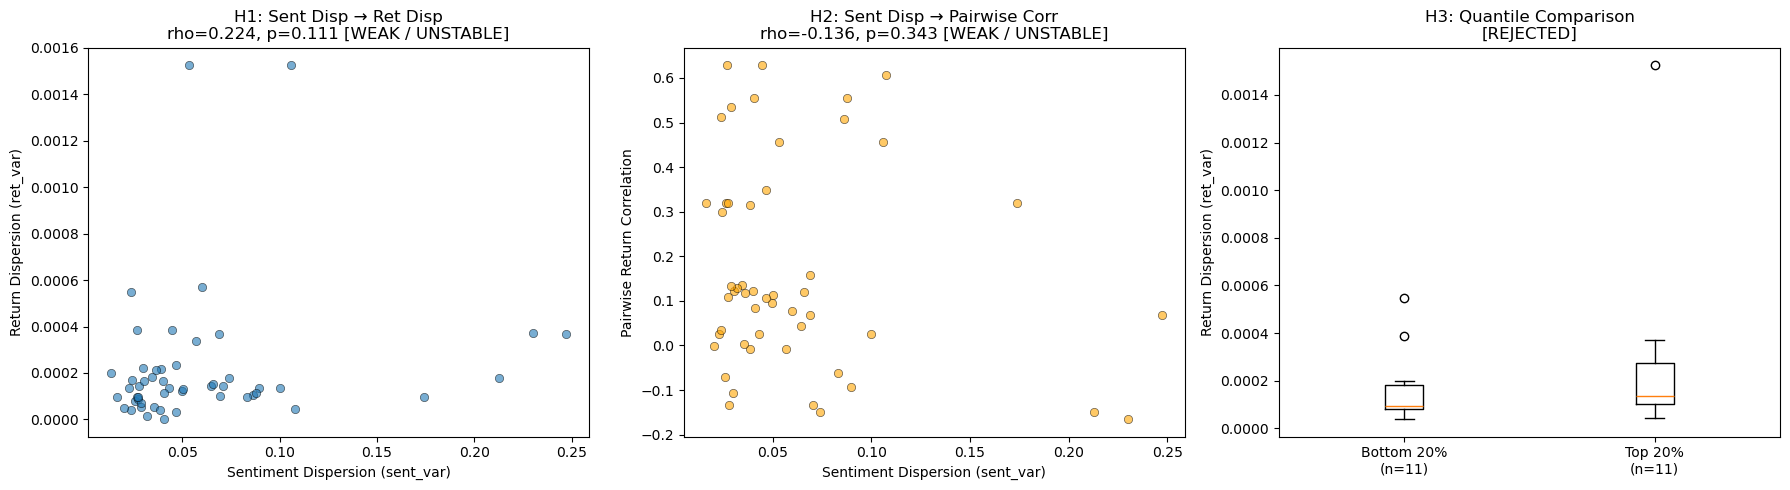

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# H1 scatter
axes[0].scatter(merged["sent_var"], merged["ret_var"], alpha=0.6, edgecolors="k", linewidth=0.5)
axes[0].set_xlabel("Sentiment Dispersion (sent_var)")
axes[0].set_ylabel("Return Dispersion (ret_var)")
axes[0].set_title(f"H1: Sent Disp → Ret Disp\nrho={rho_h1:.3f}, p={p_h1:.3f} {verdict_h1}")

# H2 scatter
h2_plot = merged.dropna(subset=["ret_pairwise_corr"])
axes[1].scatter(h2_plot["sent_var"], h2_plot["ret_pairwise_corr"], alpha=0.6, color="orange", edgecolors="k", linewidth=0.5)
axes[1].set_xlabel("Sentiment Dispersion (sent_var)")
axes[1].set_ylabel("Pairwise Return Correlation")
axes[1].set_title(f"H2: Sent Disp → Pairwise Corr\nrho={rho_h2:.3f}, p={p_h2:.3f} {verdict_h2}")

# H3 boxplot
box_data = []
box_labels = []
if len(low_days) > 0:
    box_data.append(low_days["ret_var"].dropna().values)
    box_labels.append(f"Bottom 20%\n(n={len(low_days)})")
if len(high_days) > 0:
    box_data.append(high_days["ret_var"].dropna().values)
    box_labels.append(f"Top 20%\n(n={len(high_days)})")
if box_data:
    axes[2].boxplot(box_data, labels=box_labels)
    axes[2].set_ylabel("Return Dispersion (ret_var)")
    axes[2].set_title(f"H3: Quantile Comparison\n{verdict_h3}")

plt.tight_layout()
plt.show()

## Summary: Hypothesis Test Results

Results from Deliverables 1 and 2 of the Sprint 4 Structural Analysis epic.

In [17]:
print("=" * 70)
print("HYPOTHESIS TEST SUMMARY")
print("=" * 70)
print()
print(f"  Total usable days: {len(merged)}")
print(f"  Sentiment version: v1 (dictionary-based)")
print(f"  MIN_TICKERS: {MIN_TICKERS}")
print()
print(f"  H1 (sent_var → ret_var):            rho={rho_h1:+.3f}, p={p_h1:.4f}  →  {verdict_h1}")
print(f"  H2 (sent_var → pairwise corr):      rho={rho_h2:+.3f}, p={p_h2:.4f}  →  {verdict_h2}")
print(f"  H3 (top 20% vs bottom 20% ret_var): {verdict_h3}")
print()
print("=" * 70)
print("NOTE: Small sample size limits statistical power.")
print("Proceed to lag_analysis.ipynb and regime_stability.ipynb for")
print("Deliverables 3-5 before making the go/no-go decision.")
print("=" * 70)

HYPOTHESIS TEST SUMMARY

  Total usable days: 52
  Sentiment version: v1 (dictionary-based)
  MIN_TICKERS: 5

  H1 (sent_var → ret_var):            rho=+0.224, p=0.1109  →  [WEAK / UNSTABLE]
  H2 (sent_var → pairwise corr):      rho=-0.136, p=0.3430  →  [WEAK / UNSTABLE]
  H3 (top 20% vs bottom 20% ret_var): [REJECTED]

NOTE: Small sample size limits statistical power.
Proceed to lag_analysis.ipynb and regime_stability.ipynb for
Deliverables 3-5 before making the go/no-go decision.
